In [1]:
from pathlib import Path
import random

import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pylab as plt

In [2]:
page_time = pd.read_csv("https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/web_page_data.csv")
page_time.Time *= 100
page_time

,Page,Time
0,Page A,21.0
1,Page B,253.0
2,Page A,35.0
3,Page B,71.0
4,Page A,67.0
5,Page B,85.0
6,Page A,211.0
7,Page B,246.0
8,Page A,132.0
9,Page B,149.0


In [3]:
groupA = page_time[page_time.Page == "Page A"].Time.mean()
groupB = page_time[page_time.Page == "Page B"].Time.mean()

In [4]:
groupB - groupA

np.float64(35.66666666666667)

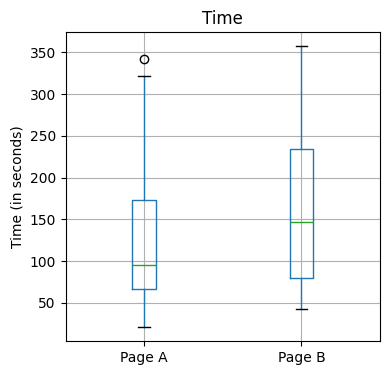

In [5]:
ax = page_time.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')

plt.tight_layout()
plt.show()


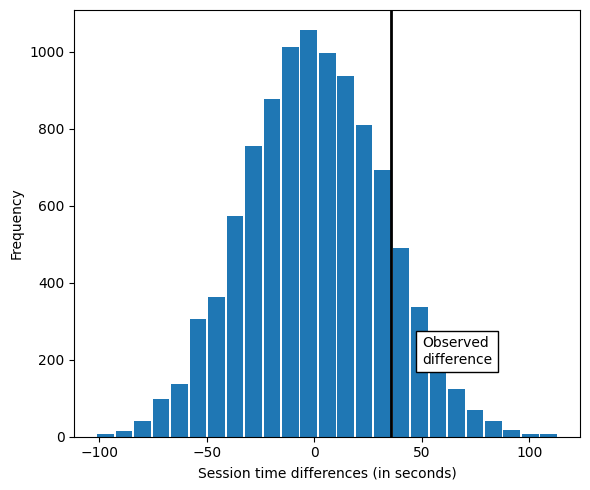

In [10]:
def permutation_func(pd_time, rows_a, rows_b) -> float:
    n = rows_a + rows_b
    idx_b = set(random.sample(range(n), rows_b))
    idx_a = set(range(n)) - idx_b
    return pd_time.loc[list(idx_b)].mean() - pd_time.loc[list(idx_a)].mean()
    
rows_a = page_time[page_time.Page == 'Page A'].shape[0]
rows_b = page_time[page_time.Page == 'Page B'].shape[0]

# permutation_test = pd.DataFrame({"difference": []})
# for i in range(10000):
#     permutation_test.loc[len(permutation_test)] = permutation_func(page_time.Time, rows_a, rows_b)
# permutation_test.plot.hist(bins=25)


perm_diffs = [permutation_func(page_time.Time, rows_a, rows_b) for _ in range(10000)]

fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(perm_diffs, bins=25, rwidth=0.9)
ax.axvline(x=groupB - groupA, color='black', lw=2)
ax.text(50, 190, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [11]:
count_data = pd.DataFrame(perm_diffs > groupB - groupA).value_counts()
count_data
print(count_data.iloc[1]/(count_data.iloc[0]+count_data.iloc[1]))
print(np.mean(perm_diffs > groupB - groupA))

0.1335
0.1335


observed difference: 0.03675791182059275
0.00040967666397872035


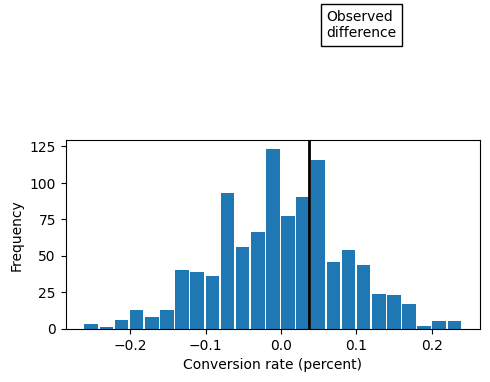

In [26]:
observed_diff = 100 * (200 / 23739 - 182 / 22588)
print(f"observed difference: {observed_diff}")
conversion = [0] * 45945 + [1] * 382
conversion = pd.Series(conversion)
permutation_diff = [100 * permutation_func(conversion, 23739, 22588) for _ in range(1000)]

# pd.Series(permutation_diff).plot.hist(bins=25)
print(np.mean(permutation_diff))

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(permutation_diff, bins=25, rwidth=0.9)
ax.axvline(x=observed_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [25]:
# P-value

print(f"p-value from permutation test: {np.mean([diff > observed_diff for diff in permutation_diff])}")

survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)
print(f'p-value for single sided test: {p_value / 2:.4f}')


p-value from permutation test: 0.325
p-value for single sided test: 0.3498


In [27]:
res = stats.ttest_ind(page_time[page_time.Page == 'Page A'].Time,
page_time[page_time.Page == 'Page B'].Time,
equal_var=False)
print(f'p-value for single sided test: {res.pvalue / 2:.4f}')

p-value for single sided test: 0.1408
